# Pima Indians Diabetes RFECV 피처 선택

## 개요
- RFECV를 활용한 최적 피처 개수 자동 탐색
- 교차검증 기반 피처 선택
- Pipeline을 통한 데이터 누수 방지

## 주요 단계
1. Pima Indians Diabetes 데이터셋 로드
2. RFECV 설정 (교차검증 기반)
3. Pipeline 구축 및 학습
4. 최적 피처 개수 확인
5. 성능 평가 및 시각화

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

## 1. 데이터 로드

**Pima Indians Diabetes 데이터셋**
- 768개 샘플, 8개 피처
- 당뇨병 발병 여부 이진 분류
- 피처: 임신 횟수, 혈당, BMI, 나이 등

In [3]:
print("Loading Pima Indians Diabetes Dataset...")
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
X = pima.data
# Convert target labels from string to integer
y = pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)

print(f"데이터 크기: {X.shape}")
print(f"클래스 분포:\n{y.value_counts()}")
print(f"\n피처 목록:\n{list(X.columns)}")

Loading Pima Indians Diabetes Dataset...
데이터 크기: (768, 8)
클래스 분포:
class
0    500
1    268
Name: count, dtype: int64

피처 목록:
['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']


**데이터 샘플 확인**

In [4]:
# 데이터 샘플
print("데이터 샘플:")
print(X.head())
print(f"\n기술 통계:")
print(X.describe())

데이터 샘플:
   preg  plas  pres  skin  insu  mass   pedi  age
0     6   148    72    35     0  33.6  0.627   50
1     1    85    66    29     0  26.6  0.351   31
2     8   183    64     0     0  23.3  0.672   32
3     1    89    66    23    94  28.1  0.167   21
4     0   137    40    35   168  43.1  2.288   33

기술 통계:
             preg        plas        pres        skin        insu        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.0

**학습/테스트 데이터 분리**
- stratify=y: 클래스 비율 유지

In [5]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 클래스 분포:\n{y_train.value_counts()}")
print(f"\nTest 클래스 분포:\n{y_test.value_counts()}")

Train: (614, 8), Test: (154, 8)

Train 클래스 분포:
class
0    400
1    214
Name: count, dtype: int64

Test 클래스 분포:
class
0    100
1     54
Name: count, dtype: int64


## 2. 문제 진단 및 해결 방법

**이전 방법의 문제점**
- SelectKBest(k=4): 고정된 피처 개수로 정보 손실 가능
- 최적 피처 개수를 사전에 알 수 없음

**해결책: RFECV**
- Recursive Feature Elimination with Cross-Validation
- 교차검증으로 최적 피처 개수 자동 탐색
- 매 단계마다 성능 평가하여 최적점 선택

## 3. RFECV 설정

**RFECV 파라미터**
- estimator: RandomForestClassifier (피처 중요도 기반)
- step=1: 한 번에 1개씩 피처 제거
- cv: StratifiedKFold(5) - 클래스 비율 유지하는 5-Fold
- scoring: accuracy
- min_features_to_select=1: 최소 1개는 선택

In [6]:
# RFECV 설정
rfecv = RFECV(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    step=1,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    min_features_to_select=1
)

print("RFECV 설정 완료")

RFECV 설정 완료


## 4. Pipeline 구축

**Pipeline 구성**
1. StandardScaler: 피처 정규화
2. RFECV: 교차검증 기반 피처 선택
3. RandomForestClassifier: 최종 분류 모델

**데이터 누수(Data Leakage) 방지**
- Pipeline 사용으로 테스트 데이터 정보 유입 차단
- 각 fold마다 독립적으로 전처리 수행

In [7]:
# Pipeline 구축
pipe_rfecv = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', rfecv),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Pipeline 구성 완료")
print(pipe_rfecv)

Pipeline 구성 완료
Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection',
                 RFECV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                       estimator=RandomForestClassifier(random_state=42),
                       scoring='accuracy')),
                ('classifier', RandomForestClassifier(random_state=42))])


## 5. 모델 학습

**학습 과정**
1. 데이터 스케일링
2. RFECV로 최적 피처 개수 탐색
3. 선택된 피처로 최종 모델 학습

In [8]:
# 학습
print("Training Pipeline with RFECV...")
pipe_rfecv.fit(X_train, y_train)
print("학습 완료!")

Training Pipeline with RFECV...
학습 완료!


## 6. 최적 피처 개수 및 선택된 피처 확인

In [9]:
# RFECV 결과 추출
rfecv_selector = pipe_rfecv.named_steps['feature_selection']
n_features_optimal = rfecv_selector.n_features_
selected_features = X.columns[rfecv_selector.support_].tolist()

print(f"최적의 피처 개수: {n_features_optimal}개 / {X.shape[1]}개")
print(f"\n선택된 피처:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

최적의 피처 개수: 6개 / 8개

선택된 피처:
  1. preg
  2. plas
  3. pres
  4. mass
  5. pedi
  6. age


**피처별 선택 여부 및 순위**

In [10]:
# 피처별 순위 확인
feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'Rank': rfecv_selector.ranking_,
    'Selected': rfecv_selector.support_
}).sort_values('Rank')

print("\n피처별 순위 (1이 선택됨):")
print(feature_ranking)


피처별 순위 (1이 선택됨):
  Feature  Rank  Selected
0    preg     1      True
1    plas     1      True
2    pres     1      True
5    mass     1      True
7     age     1      True
6    pedi     1      True
4    insu     2     False
3    skin     3     False


## 7. 모델 평가

**평가 지표**
- Accuracy: 전체 정확도
- Precision, Recall, F1-Score: 클래스별 성능

In [11]:
# 예측 및 평가
y_pred = pipe_rfecv.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7727

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



## 8. 모든 피처 vs 선택된 피처 비교

In [12]:
# 모든 피처 사용 (피처 선택 없음)
pipe_all = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipe_all.fit(X_train, y_train)
y_pred_all = pipe_all.predict(X_test)
accuracy_all = accuracy_score(y_test, y_pred_all)

# 결과 비교
print("성능 비교:")
print(f"모든 피처 사용 ({X.shape[1]}개): Accuracy = {accuracy_all:.4f}")
print(f"선택된 피처 ({n_features_optimal}개): Accuracy = {accuracy:.4f}")
print(f"\n정확도 차이: {accuracy - accuracy_all:+.4f}")
print(f"피처 감소율: {(X.shape[1] - n_features_optimal) / X.shape[1] * 100:.1f}%")

성능 비교:
모든 피처 사용 (8개): Accuracy = 0.7597
선택된 피처 (6개): Accuracy = 0.7727

정확도 차이: +0.0130
피처 감소율: 25.0%


## 9. 피처 개수에 따른 성능 변화 시각화

**RFECV 교차검증 점수 그래프**
- X축: 선택된 피처 개수
- Y축: 교차검증 정확도
- 최적 지점: 가장 높은 정확도

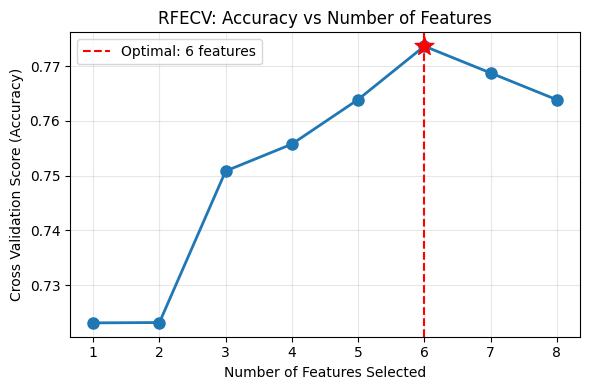

In [15]:
# 피처 개수에 따른 성능 변화 시각화
plt.figure(figsize=(6, 4))
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross Validation Score (Accuracy)")
plt.plot(
    range(1, len(rfecv_selector.cv_results_['mean_test_score']) + 1),
    rfecv_selector.cv_results_['mean_test_score'],
    marker='o',
    linewidth=2,
    markersize=8
)

# 최적 지점 표시
optimal_idx = n_features_optimal
optimal_score = rfecv_selector.cv_results_['mean_test_score'][optimal_idx - 1]
plt.axvline(x=optimal_idx, color='r', linestyle='--',
            label=f'Optimal: {optimal_idx} features')
plt.scatter([optimal_idx], [optimal_score],
            color='red', s=200, zorder=5, marker='*')

plt.title("RFECV: Accuracy vs Number of Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 교차검증 점수 상세 분석

In [16]:
# 피처 개수별 점수 데이터프레임
cv_results_df = pd.DataFrame({
    'Num_Features': range(1, len(rfecv_selector.cv_results_['mean_test_score']) + 1),
    'Mean_Score': rfecv_selector.cv_results_['mean_test_score'],
    'Std_Score': rfecv_selector.cv_results_['std_test_score']
})

# 상위 5개 결과
print("피처 개수별 교차검증 점수 (상위 5개):")
print(cv_results_df.nlargest(5, 'Mean_Score'))

피처 개수별 교차검증 점수 (상위 5개):
   Num_Features  Mean_Score  Std_Score
5             6    0.773664   0.030709
6             7    0.768772   0.034844
4             5    0.763921   0.032063
7             8    0.763881   0.031437
3             4    0.755778   0.029909
